In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/accepted_features.csv', low_memory=False)
print(df['vintage'].value_counts().sort_index())
print()
print(df['vintage'].dtype)

vintage
2007-07       2
2007-08       6
2007-09       3
2007-10       5
2007-11       8
           ... 
2018-08    2315
2018-09    1998
2018-10    2301
2018-11    2129
2018-12    2081
Name: count, Length: 138, dtype: int64

str


In [2]:
df['year'] = df['vintage'].str[:4].astype(int)
print(df['year'].value_counts().sort_index())

year
2007       31
2008      110
2009      253
2010      640
2011     1092
2012     2640
2013     6759
2014    11651
2015    21107
2016    21787
2017    22107
2018    25067
Name: count, dtype: int64


In [11]:
yearly = df.groupby("year").agg(
    total_loans = pd.NamedAgg("loan_amnt","count"),
    default_rate = pd.NamedAgg("is_default","mean"),
    avg_int_rate = pd.NamedAgg("int_rate","mean"),
    avg_loan_amnt = pd.NamedAgg("loan_amnt","mean")
).reset_index()

yearly["default_rate"] = (yearly["default_rate"]*100).round(2)
yearly["avg_int_rate"] = yearly["avg_int_rate"].round(2)
yearly['avg_loan_amnt'] = yearly['avg_loan_amnt'].round(0)

print(yearly)

    year  total_loans  default_rate  avg_int_rate  avg_loan_amnt
0   2007           31          6.45         11.58         6329.0
1   2008          110         11.82         12.41         9177.0
2   2009          253         10.28         12.46         9894.0
3   2010          640         10.78         12.10         9995.0
4   2011         1092         16.30         12.29        11612.0
5   2012         2640         16.52         13.58        13308.0
6   2013         6759         15.36         14.58        14576.0
7   2014        11651         17.41         13.82        14761.0
8   2015        21107         18.45         12.60        15173.0
9   2016        21787         17.49         13.03        14740.0
10  2017        22107         11.29         13.23        14845.0
11  2018        25067          3.81         12.73        15977.0


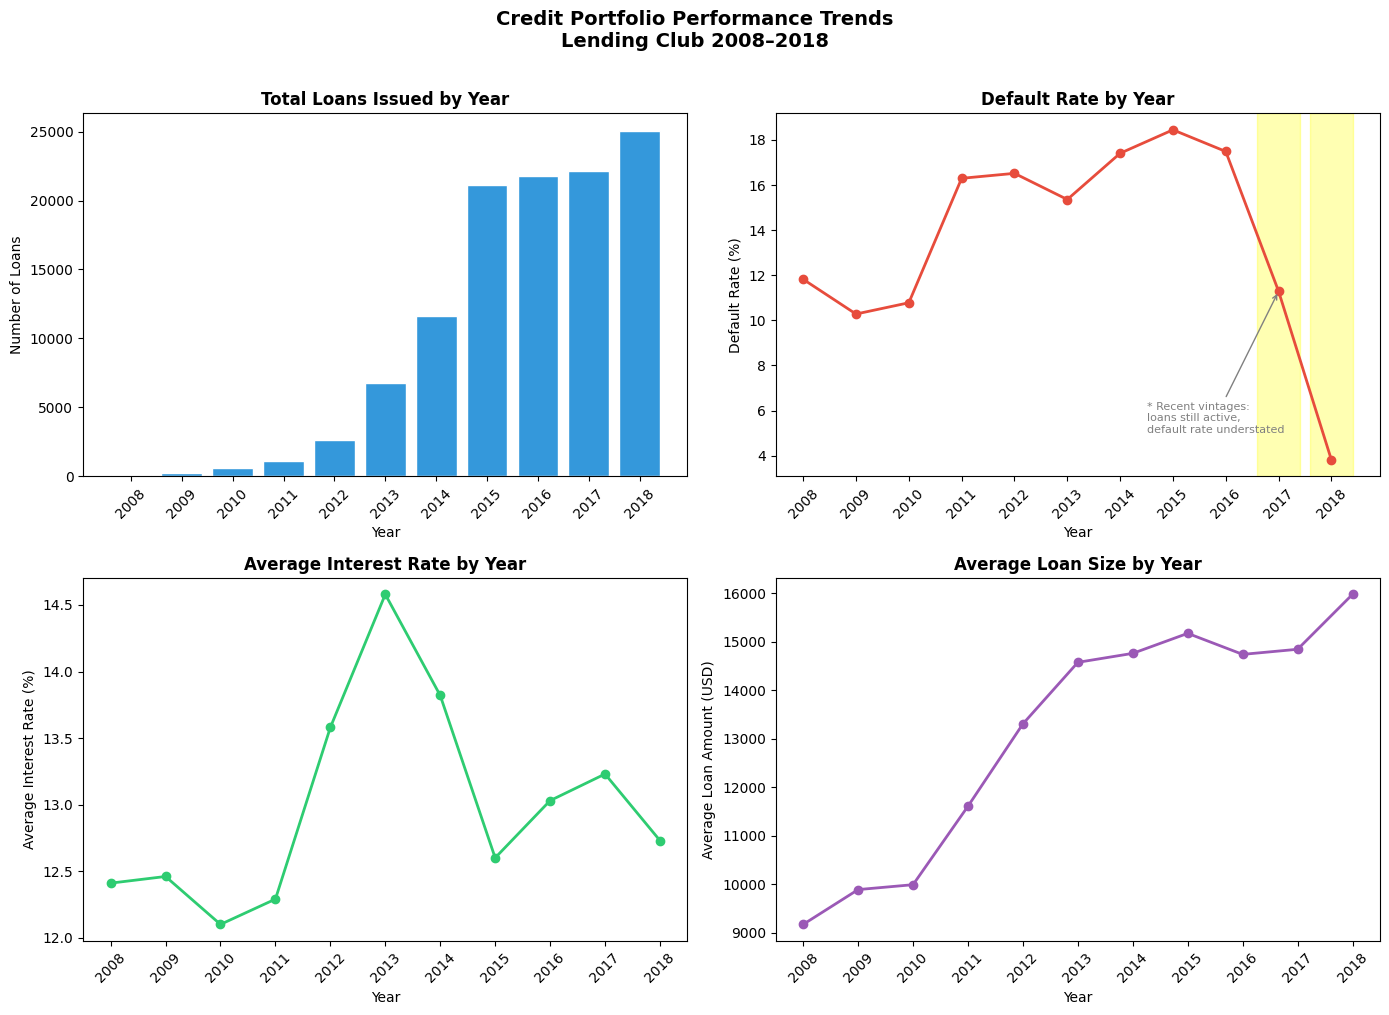

Saved.


In [17]:
plot_df = yearly[yearly['year'] >= 2008].copy()
incomplete = [2017, 2018]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Portfolio Performance Trends\nLending Club 2008–2018',
             fontsize=14, fontweight='bold', y=1.01)

ax1 = axes[0, 0]

ax1.bar(plot_df['year'], plot_df['total_loans'], color='#3498db', edgecolor='white')
ax1.set_title('Total Loans Issued by Year', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Loans')
ax1.set_xticks(plot_df['year'])
ax1.set_xticklabels(plot_df['year'], rotation=45)

ax2 = axes[0, 1]

ax2.plot(plot_df['year'], plot_df['default_rate'],
         color='#e74c3c', marker='o', linewidth=2, markersize=6)
for yr in incomplete:
    ax2.axvspan(yr - 0.4, yr + 0.4, color='yellow', alpha=0.3)

ax2.annotate('* Recent vintages:\nloans still active,\ndefault rate understated',
             xy=(2017, plot_df[plot_df['year']==2017]['default_rate'].values[0]),
             xytext=(2014.5, 5),
             fontsize=8,
             arrowprops=dict(arrowstyle='->', color='gray'),
             color='gray')

ax2.set_title('Default Rate by Year', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Default Rate (%)')
ax2.set_xticks(plot_df['year'])
ax2.set_xticklabels(plot_df['year'], rotation=45)

ax3 = axes[1, 0]

ax3.plot(plot_df['year'], plot_df['avg_int_rate'],
         color='#2ecc71', marker='o', linewidth=2, markersize=6)
ax3.set_title('Average Interest Rate by Year', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Average Interest Rate (%)')
ax3.set_xticks(plot_df['year'])
ax3.set_xticklabels(plot_df['year'], rotation=45)

ax4 = axes[1, 1]

ax4.plot(plot_df['year'], plot_df['avg_loan_amnt'],
         color='#9b59b6', marker='o', linewidth=2, markersize=6)
ax4.set_title('Average Loan Size by Year', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Average Loan Amount (USD)')
ax4.set_xticks(plot_df['year'])
ax4.set_xticklabels(plot_df['year'], rotation=45)

plt.tight_layout()
plt.savefig('../outputs/06_performance_trends.png', dpi=250, bbox_inches='tight')
plt.show()
print("Saved.")

## Interpretation: Portfolio Performance Trends (2008–2018)

### Total Loans Issued
- Lending Club grew rapidly — from 110 loans in 2008 to 25,067 in 2018
- Growth accelerated sharply from 2013 onwards as the platform scaled
- Concentration risk: over 85% of all loans were issued after 2013

### Default Rate by Year
- Mature vintages (2008–2016) show default rates between 10–19%
- Peak default rate in 2015 at 18.45% — likely reflects looser 
  underwriting standards during the platform's rapid growth phase
- 2017 and 2018 rates (11.3% and 3.8%) are understated — these are 
  recent vintages where many loans are still active and have not yet 
  had time to default (highlighted in yellow)

### Average Interest Rate by Year
- Peaked in 2013 at 14.6% — Lending Club was pricing higher risk 
  into loans as the portfolio mix shifted toward lower grades
- Dropped to 12.6% in 2015 then stabilised around 13%
- Interest rate movements reflect both market conditions and 
  the platform's changing borrower mix

### Average Loan Size by Year
- Steady increase from $9,177 (2008) to $15,977 (2018)
- Borrowers are taking on larger loans over time — increases 
  exposure per default event
- Combined with rising default rates in 2014–2016, this means 
  total credit losses were growing in absolute dollar terms

### Key takeaway
The portfolio grew aggressively from 2013–2018. Default rates 
on mature vintages stabilised between 15–18%, while rising loan 
sizes mean absolute loss exposure increased over time.